<a href="https://colab.research.google.com/github/nomanabdullah04/DeepLearning/blob/main/Vanishing_Gradient_Problem_and_Sigmoid.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

## 19. The Vanishing Gradient Problem with Sigmoid

### **Overview**
The **Vanishing Gradient Problem** occurs in deep neural networks when the gradients used to update weights become exponentially small as they are propagated backward from the output layer to the earlier layers. This causes the model to stop learning effectively in its initial layers.

### **Why it happens: The Sigmoid Constraint**
During backpropagation, we use the **Chain Rule** to compute the gradient for a weight:
$$\frac{\partial L}{\partial W_{old}} = \frac{\partial L}{\partial O_{output}} * \dots * \frac{\partial O_{hidden\_n}}{\partial O_{hidden\_n-1}} * \dots * \frac{\partial O_1}{\partial W_{old}}$$

* **The Sigmoid Derivative:** The maximum slope (derivative) of the Sigmoid activation function is only **0.25**.
* **The "Vanishing" Effect:** Every layer back in the network multiplies the gradient by a value between **0 and 0.25**.

### **Numerical Example**
Imagine a 4-layer network. During backpropagation, we multiply the derivatives across these layers:

* **Gradient Calculation:**
  $$\text{Gradient} = \text{Term}_1 \times \text{Term}_2 \times \text{Term}_3 \times \text{Term}_4$$
* **If each term is $\le 0.25$:**
  $$\text{Gradient} \approx 0.25 \times 0.25 \times 0.25 \times 0.25 = \mathbf{0.0039}$$

As you add more layers, this value approaches **zero**.


### **Impact on Training**
When we use this gradient in our **Weight Updation Formula**:
$$W_{new} = W_{old} - \eta \left( \text{Gradient} \right)$$
$$W_{new} = W_{old} - \eta \left( 0.0039 \right)$$
$$W_{new} \approx W_{old}$$

**Conclusion:** Because the gradient is nearly zero, the weight $W_{new}$ stays almost identical to $W_{old}$. The earlier layers in the network do not "learn," rendering the deep architecture ineffective. To solve this, practitioners often use alternative activation functions like **ReLU (Rectified Linear Unit)**, which do not suffer from the same small derivative constraints as the Sigmoid function.

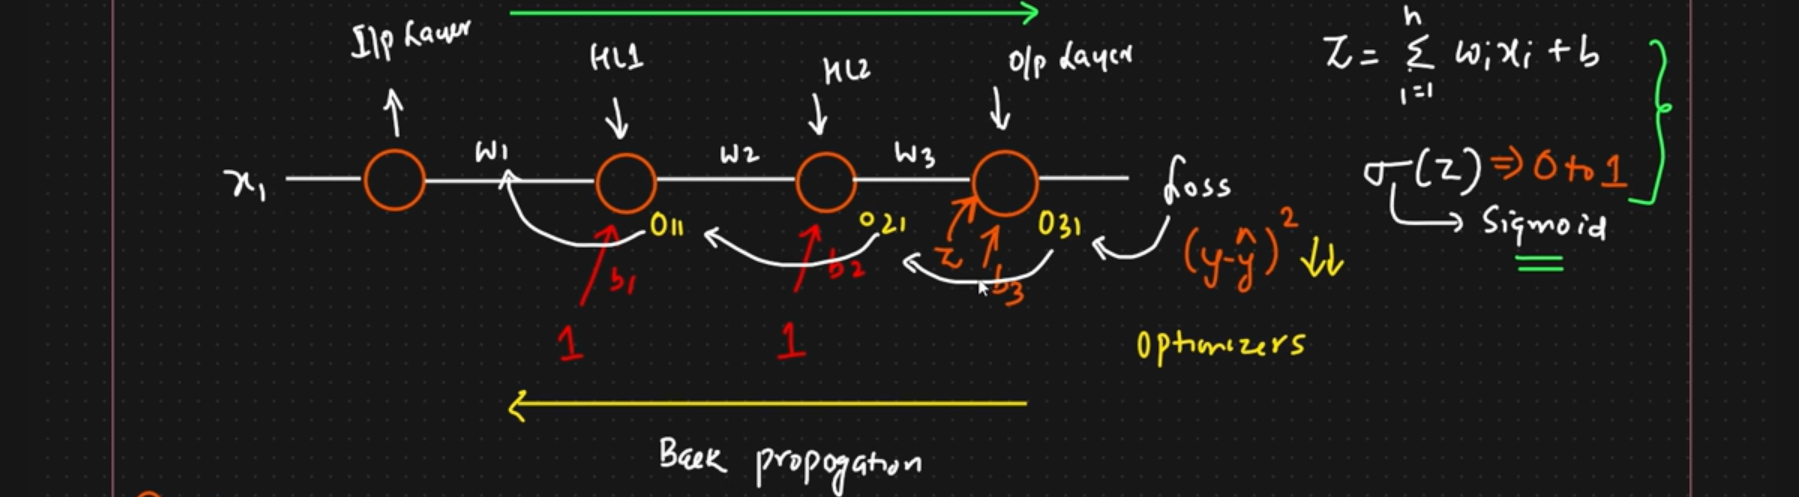
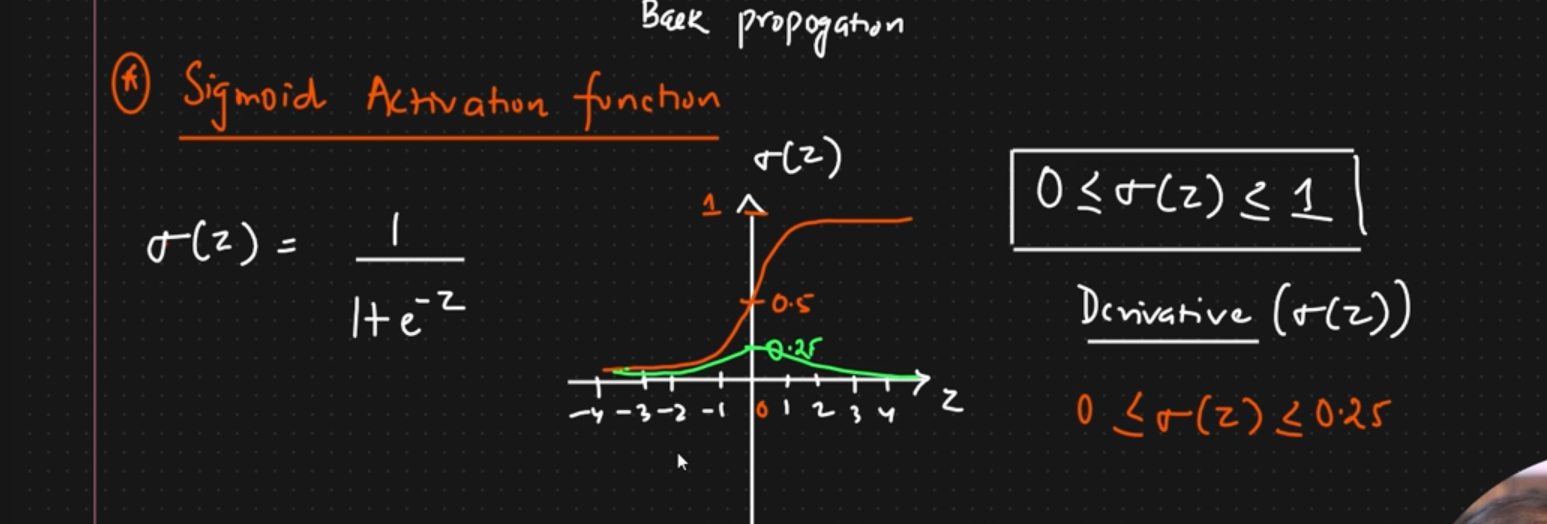

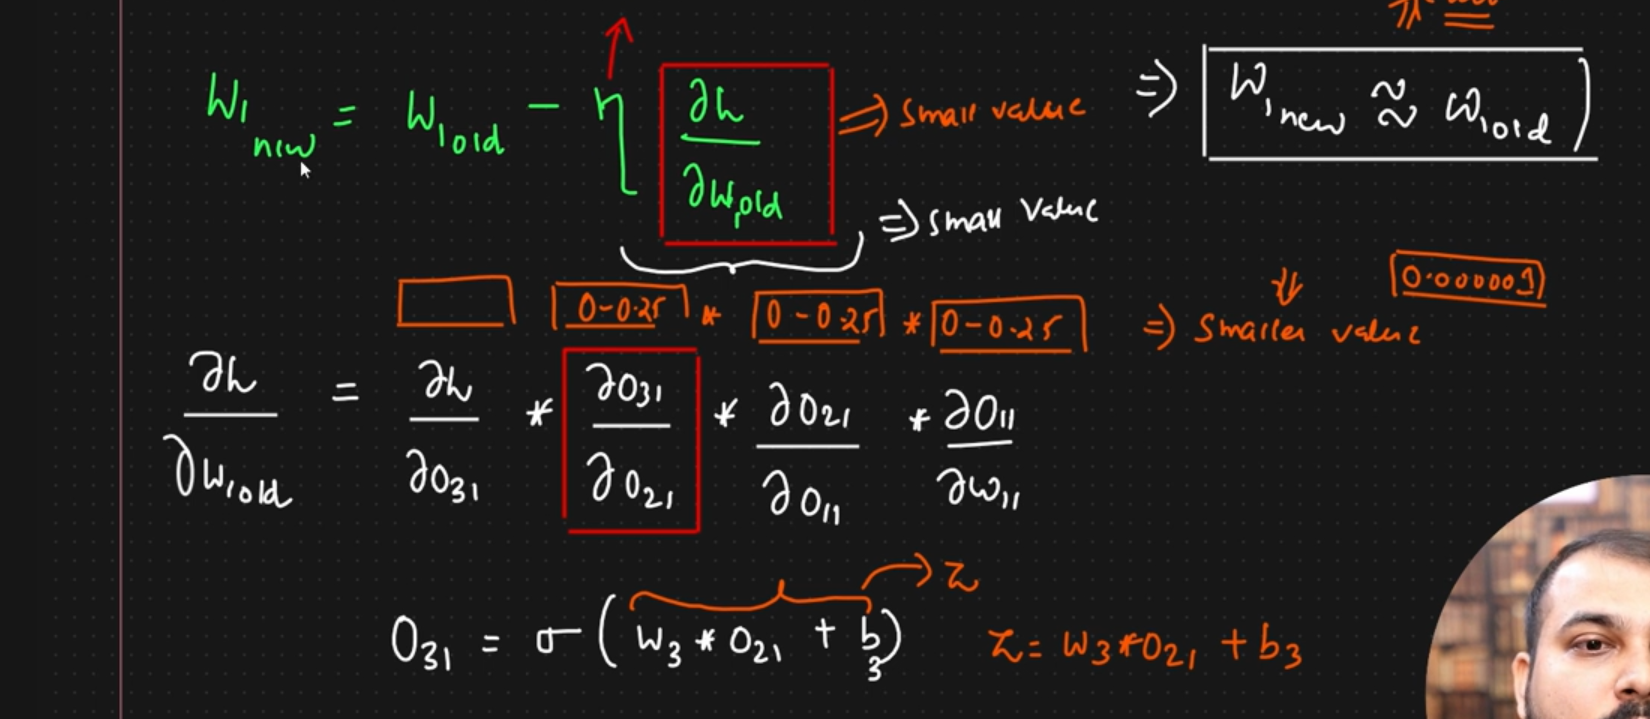

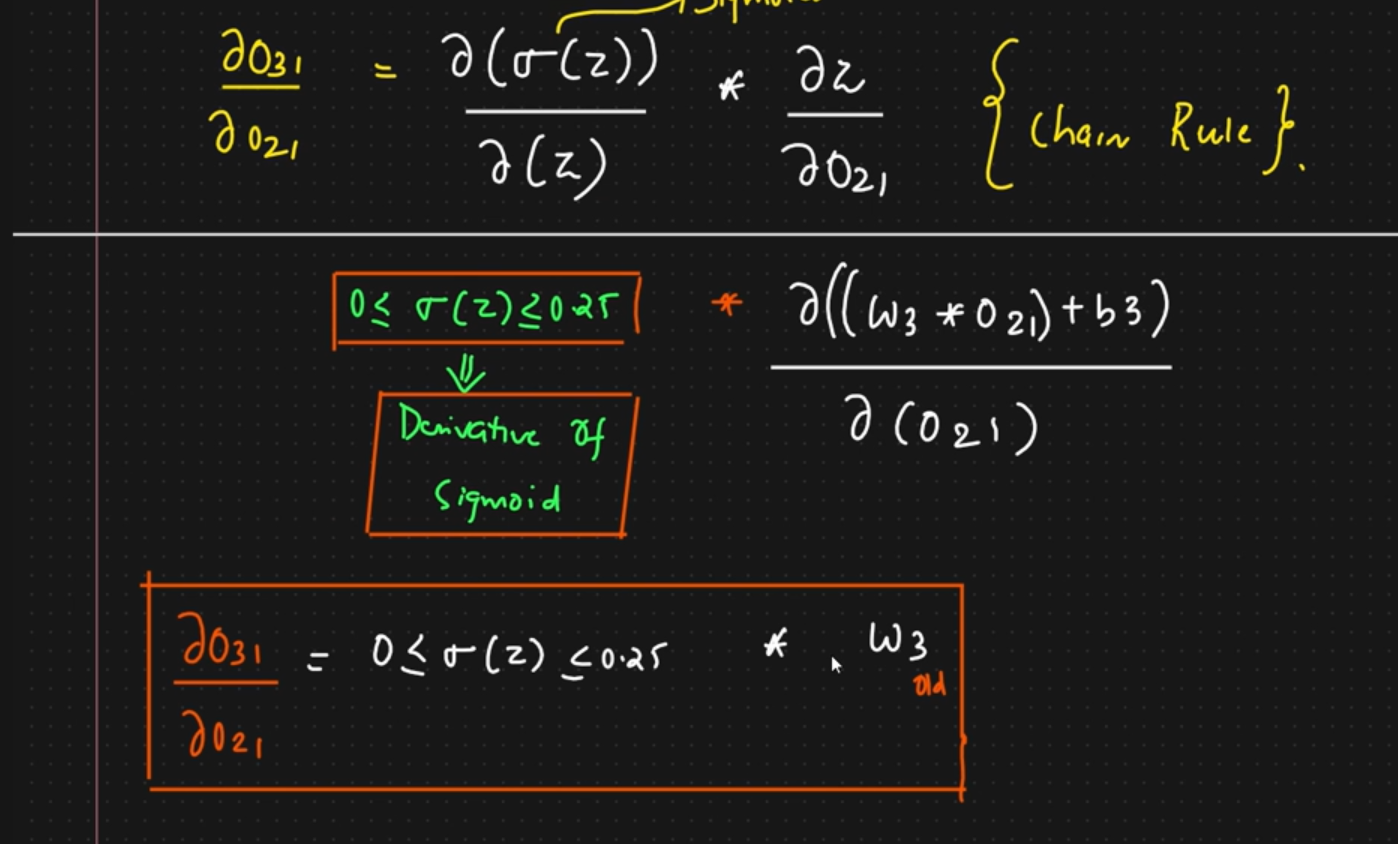

## 20. Solutions to the Vanishing Gradient Problem

### **Why Alternatives are Needed**
As we saw, using the Sigmoid activation function in deep networks causes gradients to shrink drastically during backpropagation due to its maximum derivative limit of $0.25$. To build deeper, effective networks, we need solutions that allow gradients to flow freely without shrinking to zero.


### **Primary Solutions**

1. **Alternative Activation Functions (e.g., ReLU - Rectified Linear Unit)**
   * **Formula:** $\text{ReLU}(x) = \max(0, x)$
   * **Why it helps:** For any positive input, the derivative (slope) of ReLU is exactly **$1$**. When multiplying gradients backward during backpropagation, multiplying by $1$ prevents the gradient from shrinking exponentially.

2. **Residual Connections / Skip Connections (ResNets)**
   * Allows gradients to bypass layers directly via "shortcut connections," ensuring backpropagation can reach earlier layers unimpeded.

3. **Proper Weight Initialization**
   * Using advanced initialization techniques (like Xavier or He initialization) ensures weights start at optimal scales to prevent premature gradient saturation.